In [54]:
from qiskit.circuit import QuantumCircuit, CircuitInstruction
from qiskit.circuit.library import SwapGate
from networkx import Graph, isomorphism, draw
from ag import *

gates: 28, depth: 10


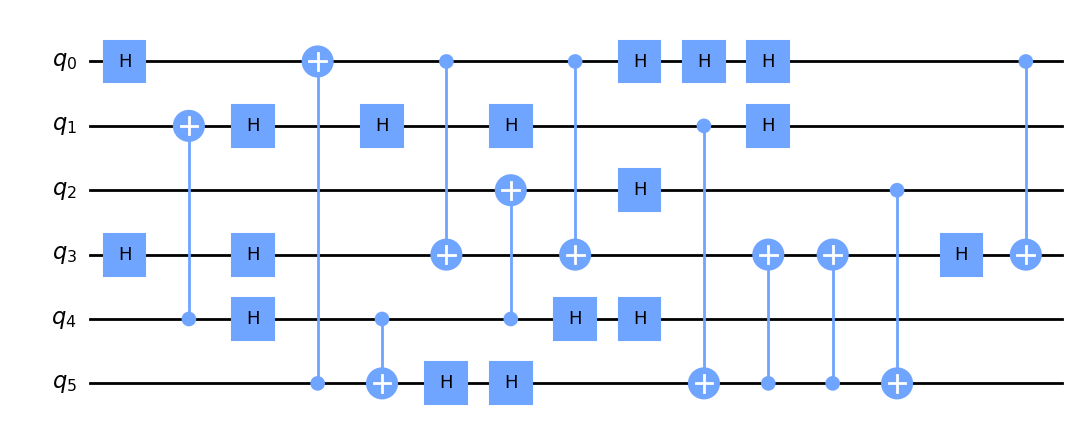

In [55]:
ARCH = qgrid(2, 3)
CIRC = QuantumCircuit.from_qasm_file("benchmark/BNTF/6QBT_large_gate_opt1_1_1.5_no.8.qasm")

original_gate_set = CIRC.data.copy()
print(f"gates: {len(CIRC)}, depth: {CIRC.depth()}")
CIRC.draw("mpl")

In [61]:
def circuit_to_graph(circuit: QuantumCircuit) -> Graph:
    
    qubit_map = {q: q for q in circuit.qubits}
    circuit_graph = Graph()
    circuit_graph.add_nodes_from(circuit.qubits)
    
    for gate in circuit.data:
        p = gate.qubits[0]
        if len(gate.qubits) < 2:
            continue
        q = gate.qubits[1]
        if gate.operation.name == "swap":
            qubit_map[p], qubit_map[q] = qubit_map[q], qubit_map[p]
            continue
        if not circuit_graph.has_edge(qubit_map[p], qubit_map[q]):
            circuit_graph.add_edge(qubit_map[p], qubit_map[q])

    return circuit_graph

In [68]:
valid_circuits: list[QuantumCircuit] = list()

for i in range(len(original_gate_set) + 1): # loop through sequence of gates
    for p in range(CIRC.num_qubits):
        for q in range(p + 1, CIRC.num_qubits):
            swap = CircuitInstruction(SwapGate(), [p, q]) # create SWAP(p, q)
            CIRC.data = original_gate_set
            CIRC.data.insert(i, swap) # insert SWAP gate at index i of the gate sequence
            GM = isomorphism.GraphMatcher(ARCH, circuit_to_graph(CIRC))
            if GM.subgraph_is_isomorphic(): # check if circuit is embeddable onto architecture
                valid_circuits.append(CIRC.copy())

In [71]:
for circuit in valid_circuits:
    decomposed_circuit = circuit.decompose("swap")
    print(f"depth overhead: {decomposed_circuit.depth() - CIRC.depth()}")

depth overhead: 3
